# Day 12 — Model bake-off (hands-on)

Build the script that runs the **same prompts against 2–3 real models** and produces the
cost / latency / accuracy table you learned to read on Day 11. Today the models are real
(two sizes of SmolLM2 + a non-instruct baseline), running on CPU, and the numbers are
measured, not assumed.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The task, the gold set, the price table | 6 min |
| 1 | A uniform model adapter (local + how to add an API model) | 12 min |
| 2 | The scoring functions: format + correctness | 8 min |
| 3 | Run the bake-off | 12 min |
| 4 | The comparison table + Pareto plot | 12 min |
| 5 | Sensitivity: prompt wording and sampling | 7 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**. First run downloads ~2 small models (~500 MB total).

In [1]:
import os, time, json, re, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import numpy as np, torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


## 0 — Task, gold set, price table (6 min)

Task: classify a support ticket into `billing | bug | account | feature | other` and output
**exactly one lowercase word**. Simple to score, and format-adherence itself separates models.

In [2]:
GOLD = [
 ("I was double charged for my subscription and want a refund.", "billing"),
 ("The export button does nothing when I click it.", "bug"),
 ("I can't log in, my account says it's locked.", "account"),
 ("Please add a dark mode to the dashboard.", "feature"),
 ("What are your business hours?", "other"),
 ("My invoice has the wrong VAT number.", "billing"),
 ("The app crashes on startup after the last update.", "bug"),
 ("How do I change my email address?", "account"),
 ("It would be great to have a Slack integration.", "feature"),
 ("Your pricing page has a typo.", "other"),
 ("I was billed after I cancelled last month.", "billing"),
 ("Search returns no results even for exact titles.", "bug"),
]
LABELS = ["billing", "bug", "account", "feature", "other"]

# Illustrative price table ($ per 1M tokens). Local models: a notional "self-host" cost
# scaled by parameter count. Swap in real API models + real prices to compare.
PRICES = {
 "Qwen2.5-0.5B": dict(pin=0.06, pout=0.06),
 "SmolLM2-360M": dict(pin=0.05, pout=0.05),
 "SmolLM2-135M": dict(pin=0.02, pout=0.02),
 "distilgpt2":   dict(pin=0.02, pout=0.02),
 # "claude-haiku": dict(pin=0.80, pout=4.00),   # add real models + real prices here
}
print(len(GOLD), "tickets;", len(LABELS), "labels")

12 tickets; 5 labels


## 1 — A uniform model adapter (12 min)

Every model — local or API — hides behind one interface:
`complete(system, user) -> dict(text, latency_s, tok_in, tok_out)`. The bake-off code never
knows which kind it's talking to.

In [3]:
class LocalHF:
    def __init__(self, name, hf_id, chat=True, max_new=6):
        self.name, self.chat, self.max_new = name, chat, max_new
        self.tok = AutoTokenizer.from_pretrained(hf_id)
        if self.tok.pad_token is None: self.tok.pad_token = self.tok.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(hf_id).to(DEVICE).eval()

    def _prompt(self, system, user):
        if self.chat and self.tok.chat_template:
            msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
            enc = self.tok.apply_chat_template(msgs, add_generation_prompt=True,
                                               return_tensors="pt", return_dict=True)
            return {k: v.to(DEVICE) for k, v in enc.items()}
        text = f"{system}\n\n{user}"
        return self.tok(text, return_tensors="pt").to(DEVICE)

    def complete(self, system, user):
        enc = self._prompt(system, user)
        n_in = enc["input_ids"].shape[1]
        t0 = time.perf_counter()
        with torch.no_grad():
            out = self.model.generate(**enc, max_new_tokens=self.max_new, do_sample=False,
                                      pad_token_id=self.tok.eos_token_id)
        dt = time.perf_counter() - t0
        gen = out[0][n_in:]
        text = self.tok.decode(gen, skip_special_tokens=True).strip()
        return dict(text=text, latency_s=dt, tok_in=int(n_in),
                    tok_out=int((gen != self.tok.eos_token_id).sum()))

# ---- how to add an API model (uncomment, add key + 'anthropic' to requirements) ----
# import anthropic
# class ClaudeAPI:
#     def __init__(self, name, model): self.name, self.model = name, model; self.c = anthropic.Anthropic()
#     def complete(self, system, user):
#         t0 = time.perf_counter()
#         r = self.c.messages.create(model=self.model, max_tokens=12, system=system,
#                                    messages=[{"role":"user","content":user}])
#         return dict(text=r.content[0].text.strip(), latency_s=time.perf_counter()-t0,
#                     tok_in=r.usage.input_tokens, tok_out=r.usage.output_tokens)

MODELS = [
    LocalHF("Qwen2.5-0.5B", "Qwen/Qwen2.5-0.5B-Instruct"),
    LocalHF("SmolLM2-360M", "HuggingFaceTB/SmolLM2-360M-Instruct"),
    LocalHF("SmolLM2-135M", "HuggingFaceTB/SmolLM2-135M-Instruct"),
]
print("loaded:", [m.name for m in MODELS])

loaded: ['Qwen2.5-0.5B', 'SmolLM2-360M', 'SmolLM2-135M']


## 2 — Scoring: format + correctness (8 min)

Two separate scores (Day 06's lesson): did it obey the format, and was it right?

In [4]:
FEWSHOT = (
 'Examples:\n'
 'Ticket: "I was billed twice." -> billing\n'
 'Ticket: "The page shows a 500 error." -> bug\n'
 'Ticket: "Reset my password please." -> account\n'
 'Ticket: "Add CSV export." -> feature\n'
 'Ticket: "Where are you located?" -> other\n')
SYSTEM = ("You are a support ticket classifier. Categories: billing, bug, account, feature, "
          "other. Reply with only the one category word.\n" + FEWSHOT)
USER_TMPL = 'Ticket: "{ticket}" ->'

def parse_label(text):
    m = re.search(r"\b(billing|bug|account|feature|other)\b", text.lower())
    return m.group(1) if m else None

def score_one(text, gold):
    word = text.strip().split()[0].lower().strip(".,:;\"'") if text.strip() else ""
    format_ok = int(word in LABELS and len(text.strip().split()) == 1)
    pred = parse_label(text)                       # lenient: find a label anywhere
    correct = int(pred == gold)
    return format_ok, correct, pred

print(score_one("billing", "billing"))
print(score_one("This is a billing issue.", "billing"))   # correct label, bad format
print(score_one("I'm sorry to hear that", "billing"))     # neither

(1, 1, 'billing')
(0, 1, 'billing')
(0, 0, None)


## 3 — Run the bake-off (12 min)

In [5]:
rows = []
for m in MODELS:
    for ticket, gold in GOLD:
        r = m.complete(SYSTEM, USER_TMPL.format(ticket=ticket))
        fmt, corr, pred = score_one(r["text"], gold)
        rows.append(dict(model=m.name, gold=gold, pred=pred, fmt=fmt, correct=corr,
                         latency=r["latency_s"], tok_in=r["tok_in"], tok_out=r["tok_out"],
                         raw=r["text"][:60]))
    print(f"{m.name}: done")

# peek at a few raw outputs
print()
for row in rows[:2] + rows[12:14] + rows[24:26]:
    print(f"  {row['model']:13s} gold={row['gold']:8s} -> {row['raw']!r}")

Qwen2.5-0.5B: done


SmolLM2-360M: done


SmolLM2-135M: done

  Qwen2.5-0.5B  gold=billing  -> 'billing'
  Qwen2.5-0.5B  gold=bug      -> 'bug'
  SmolLM2-360M  gold=billing  -> 'other'
  SmolLM2-360M  gold=bug      -> 'other'
  SmolLM2-135M  gold=billing  -> 'I apologize for the inconvenience caused'
  SmolLM2-135M  gold=bug      -> 'The export button does nothing when'


## 4 — The comparison table + Pareto plot (12 min)

In [6]:
def cost_of(row):
    p = PRICES[row["model"]]
    return (row["tok_in"]*p["pin"] + row["tok_out"]*p["pout"]) / 1e6

import collections
agg = collections.defaultdict(list)
for r in rows: agg[r["model"]].append(r)

summary = []
for name, rs in agg.items():
    summary.append(dict(
        model=name,
        accuracy=np.mean([r["correct"] for r in rs]),
        format_ok=np.mean([r["fmt"] for r in rs]),
        p50_latency=np.percentile([r["latency"] for r in rs], 50),
        p95_latency=np.percentile([r["latency"] for r in rs], 95),
        cost_1k=1000*np.mean([cost_of(r) for r in rs]),
        mean_tok_out=np.mean([r["tok_out"] for r in rs]),
    ))
summary.sort(key=lambda d: -d["accuracy"])

print(f"{'model':14s} {'acc':>6} {'fmt_ok':>7} {'p50 s':>7} {'p95 s':>7} {'$/1k':>9} {'out_tok':>8}")
for d in summary:
    print(f"{d['model']:14s} {d['accuracy']:>6.2f} {d['format_ok']:>7.2f} {d['p50_latency']:>7.2f} "
          f"{d['p95_latency']:>7.2f} {d['cost_1k']:>9.4f} {d['mean_tok_out']:>8.1f}")

model             acc  fmt_ok   p50 s   p95 s      $/1k  out_tok
Qwen2.5-0.5B     0.83    1.00    0.97    1.79    0.0069      1.0
SmolLM2-360M     0.17    1.00    1.03    1.66    0.0063      1.0
SmolLM2-135M     0.00    0.00    0.46    0.66    0.0026      6.0


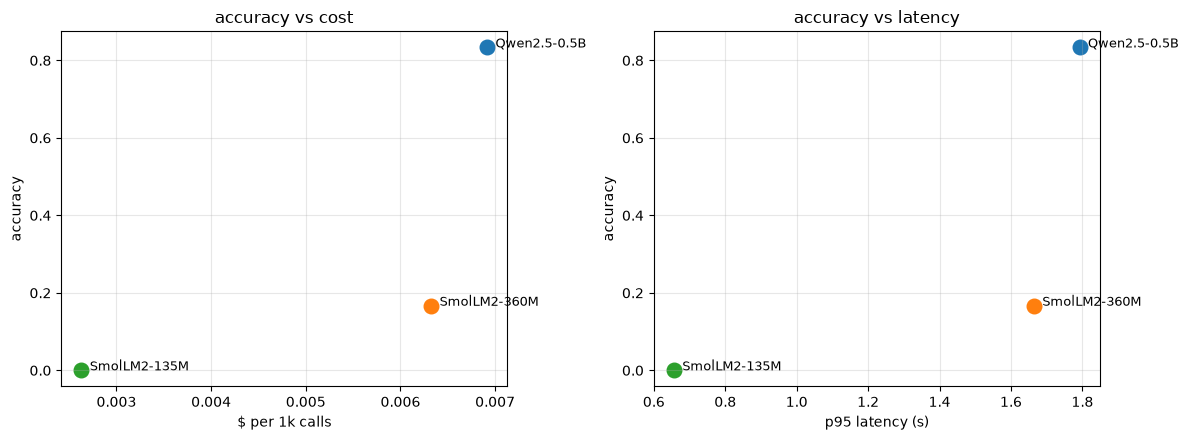

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for d in summary:
    ax[0].scatter(d["cost_1k"], d["accuracy"], s=110)
    ax[0].annotate(d["model"], (d["cost_1k"], d["accuracy"]), xytext=(6,0),
                   textcoords="offset points", fontsize=9)
ax[0].set_xlabel("$ per 1k calls"); ax[0].set_ylabel("accuracy")
ax[0].set_title("accuracy vs cost"); ax[0].grid(alpha=.3)
for d in summary:
    ax[1].scatter(d["p95_latency"], d["accuracy"], s=110)
    ax[1].annotate(d["model"], (d["p95_latency"], d["accuracy"]), xytext=(6,0),
                   textcoords="offset points", fontsize=9)
ax[1].set_xlabel("p95 latency (s)"); ax[1].set_ylabel("accuracy")
ax[1].set_title("accuracy vs latency"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [8]:
# confusion for the best model
best = summary[0]["model"]
ci = {l:i for i,l in enumerate(LABELS)}
M = np.zeros((5,5), int)
for r in agg[best]:
    if r["pred"] in ci: M[ci[r["gold"]], ci[r["pred"]]] += 1
print(f"confusion matrix for {best}  (rows=true, cols=pred):", LABELS)
print(M)
print("\nTypical findings:")
print(" - Qwen2.5-0.5B (with the few-shot prompt) actually discriminates the categories")
print(" - the SmolLM2 models often collapse to one label or emit prose -> low acc + low fmt")
print(" - all three cost about the same here; capability, not price, is the deciding axis")
print(" - 0.5B params is enough for this task; 135-360M is not -- size threshold is real")

confusion matrix for Qwen2.5-0.5B  (rows=true, cols=pred): ['billing', 'bug', 'account', 'feature', 'other']
[[3 0 0 0 0]
 [0 3 0 0 0]
 [0 0 2 0 0]
 [0 0 0 2 0]
 [1 0 1 0 0]]

Typical findings:
 - Qwen2.5-0.5B (with the few-shot prompt) actually discriminates the categories
 - the SmolLM2 models often collapse to one label or emit prose -> low acc + low fmt
 - all three cost about the same here; capability, not price, is the deciding axis
 - 0.5B params is enough for this task; 135-360M is not -- size threshold is real


## 5 — Sensitivity (7 min)

Change the prompt wording or turn on sampling — does the ranking hold? If a 2-word change
flips the winner, your bake-off isn't measuring capability yet.

In [9]:
SYSTEM_V2 = ("Classify this customer support ticket. Output only the single category word, "
             "one of: billing, bug, account, feature, other.\n" + FEWSHOT)

def quick_eval(model, system, sample=False):
    accs, fmts = [], []
    for ticket, gold in GOLD:
        enc = model._prompt(system, USER_TMPL.format(ticket=ticket))
        n_in = enc["input_ids"].shape[1]
        with torch.no_grad():
            out = model.model.generate(**enc, max_new_tokens=6, do_sample=sample,
                                       temperature=0.8 if sample else None,
                                       pad_token_id=model.tok.eos_token_id)
        text = model.tok.decode(out[0][n_in:], skip_special_tokens=True).strip()
        f, c, _ = score_one(text, gold); accs.append(c); fmts.append(f)
    return np.mean(accs), np.mean(fmts)

print(f"{'model':14s} {'v1 acc':>7} {'v2 acc':>7} {'v1 fmt':>7} {'v2 fmt':>7}")
for m in MODELS:
    a1, f1 = quick_eval(m, SYSTEM)
    a2, f2 = quick_eval(m, SYSTEM_V2)
    print(f"{m.name:14s} {a1:>7.2f} {a2:>7.2f} {f1:>7.2f} {f2:>7.2f}")
print("\n-> if v1 and v2 disagree on the ranking, report BOTH and test more prompts before")
print("   picking a model. Never choose on a single prompt phrasing.")

model           v1 acc  v2 acc  v1 fmt  v2 fmt


Qwen2.5-0.5B      0.83    0.83    1.00    1.00


SmolLM2-360M      0.17    0.17    1.00    1.00


SmolLM2-135M      0.00    0.00    0.00    0.00

-> if v1 and v2 disagree on the ranking, report BOTH and test more prompts before
   picking a model. Never choose on a single prompt phrasing.


## 6 — Exercises

1. **Add a model.** Add `distilgpt2` with a hand-written few-shot prompt (3 examples in the
   system message). Does few-shot rescue a non-instruct model's format adherence?
2. **Real prices.** Replace `PRICES` with current Haiku / GPT-nano / Flash numbers (look them
   up). Re-plot. Where does a cheap API model land vs the local models on the cost/accuracy
   plane?
3. **Latency under load.** Wrap `complete` to run 3 tickets concurrently with
   `concurrent.futures` and measure throughput (tickets/sec) per model.
4. **Format-forgiving score.** You add a downstream regex parser that extracts the label from
   any output. Recompute accuracy with the lenient `parse_label`. Which model's *effective*
   accuracy jumps most, and what does that tell you?
5. **Pick for a scenario.** Bar = 0.85 accuracy, p95 < 1.5s, ≤ $0.50/1k calls. Which model (if
   any) qualifies from your table? If none, what's your next move (Day 07 options)?
6. **Disagreement set.** Find the tickets where the two SmolLM2 models disagree. Are those the
   genuinely ambiguous ones? (This set is gold for expanding your eval.)

> **Attempt every exercise and the quiz first.** The worked solutions and the answer key live in [`solutions/solutions.ipynb`](solutions/solutions.ipynb) — open it only to check your work, not to start.

## Self-check quiz


1. Why does every model in the harness hide behind the same `complete()` signature?
2. Why score format adherence separately from correctness?
3. Two prompt phrasings give different model rankings. What do you do?
4. Your best local model clears the accuracy bar but not the latency bar on CPU. Name two
   fixes that don't involve changing the model.
5. A model's strict accuracy is 0.55 but lenient (regex-parsed) accuracy is 0.85. What does
   that gap mean, and is it a problem?
6. Why is the set of tickets where two models disagree valuable?
7. You measured everything on 12 tickets. What's the honest caveat when you report the winner?

## Where this goes next

Week 4 done — you can benchmark, reason about tradeoffs, and run a real multi-model bake-off.
**Week 5 starts the retrieval track: embeddings and vector databases** — how semantic search
actually works, built from cosine similarity up (Day 13).